# Dynamic Equilibrium Governance

This notebook serves as an interactive archive of the **Cybernetic Resource Economy** architecture. By deconstructing the systemic failures of capitalism, socialism, and communism, we synthesize a system optimized for steady-state growth and Gini index minimization.

The architecture relies on two primary algorithms:
1. **The Kinetic Governor**: An asymptotic wealth cap.
2. **The Anchor**: A physical resource tax based on Georgist principles.

### 1. The Asymptotic Wealth Cap (The Kinetic Governor)

To prevent capital consolidation while maintaining the mathematical incentive to produce, we apply a continuously differentiable marginal tax rate (MTR) function:

$$ MTR(W) = T_{max} \times (1 - e^{-k \cdot W}) $$

Where:
*   $W$: Wealth/Revenue Stream
*   $T_{max}$: The limit (e.g., 0.99)
*   $k$: The dynamic decay constant

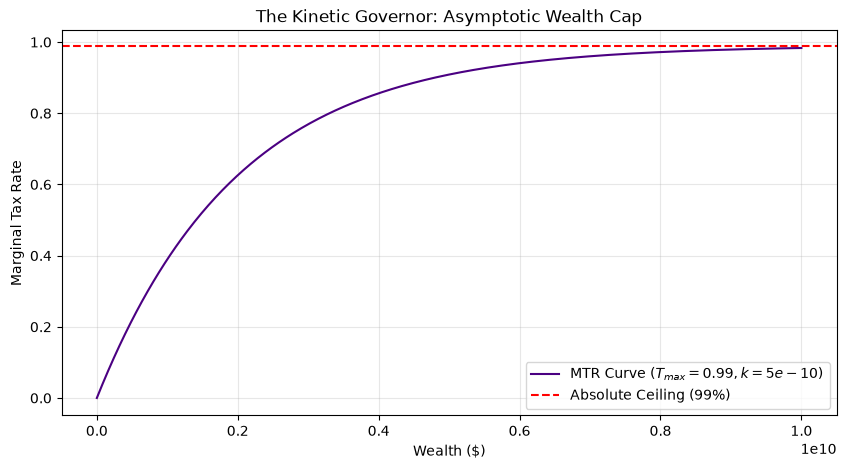

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_mtr(W, T_max=0.99, k=1e-9):
    """
    Calculates the Marginal Tax Rate using an asymptotic curve.
    W: Wealth in dollars
    T_max: Maximum tax rate ceiling (default 99%)
    k: Decay constant controlling the ramp-up speed
    """
    return T_max * (1 - np.exp(-k * W))

# Visualize the Kinetic Governor
wealth_levels = np.linspace(0, 10_000_000_000, 500) # Up to $10 Billion
mtr_rates = calculate_mtr(wealth_levels, T_max=0.99, k=5e-10)

plt.figure(figsize=(10, 5))
plt.plot(wealth_levels, mtr_rates, label='MTR Curve ($T_{max}=0.99, k=5e-10$)', color='indigo')
plt.axhline(y=0.99, color='r', linestyle='--', label='Absolute Ceiling (99%)')
plt.title('The Kinetic Governor: Asymptotic Wealth Cap')
plt.xlabel('Wealth ($)')
plt.ylabel('Marginal Tax Rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 2. The Physical Resource Tax (The Anchor)

To close capital flight loopholes, the system taxes the monopolization of physical and public resources rather than abstract capital or labor.

$$ Tax_{Resource} = \sum (A \cdot V_{L}) + (E \cdot C_{R}) + (B \cdot V_{N}) $$

Where:
*   $A \cdot V_{L}$: Physical area $\times$ unimproved network value of the location.
*   $E \cdot C_{R}$: Extracted raw materials/energy $\times$ replacement cost to the biosphere.
*   $B \cdot V_{N}$: Bandwidth/Spectrum footprint $\times$ network value.

In [2]:
def calculate_resource_tax(land_area, land_value, extraction_vol, replacement_cost, bandwidth_used, network_value):
    """
    Calculates the physical holding fee for monopolized resources.
    """
    land_tax = land_area * land_value
    extraction_tax = extraction_vol * replacement_cost
    bandwidth_tax = bandwidth_used * network_value
    
    total_tax = land_tax + extraction_tax + bandwidth_tax
    return {
        'Land Tax': land_tax,
        'Extraction Tax': extraction_tax,
        'Bandwidth Tax': bandwidth_tax,
        'Total Resource Tax': total_tax
    }

# Example: A tech monopoly hoarding land, server cooling water, and spectrum
entity_tax_profile = calculate_resource_tax(
    land_area=50000, land_value=200,          # 50k acres * $200 network value multiplier
    extraction_vol=1000000, replacement_cost=0.05, # 1M gallons water * $0.05 replacement
    bandwidth_used=500, network_value=1000     # 500 MHz spectrum * 1000 network value
)

for category, amount in entity_tax_profile.items():
    print(f"{category}: ${amount:,.2f}")

Land Tax: $10,000,000.00
Extraction Tax: $50,000.00
Bandwidth Tax: $500,000.00
Total Resource Tax: $10,550,000.00


### 3. The Dynamic Decay Constant ($k$)

The decay constant is not static; it is a macro-level risk management algorithm. It modulates wealth recycling based on the business cycle, increasing friction during irrational exuberance and decreasing it during periods of negative growth. Crucially, when perfectly free markets drive profit to zero, wealth recycling enters standby mode.

$$ k(t) = \lambda \cdot \Pi_{sys}(t) \cdot e^{\gamma \cdot \Delta M(t)} $$

Where:
* $\Pi_{sys}(t)$: Aggregate systemic profit margin.
* $\Delta M(t)$: Macroeconomic variance (Actual Growth - Target Growth + Asset Inflation).
* $\lambda, \gamma$: Systemic scaling and elasticity coefficients.

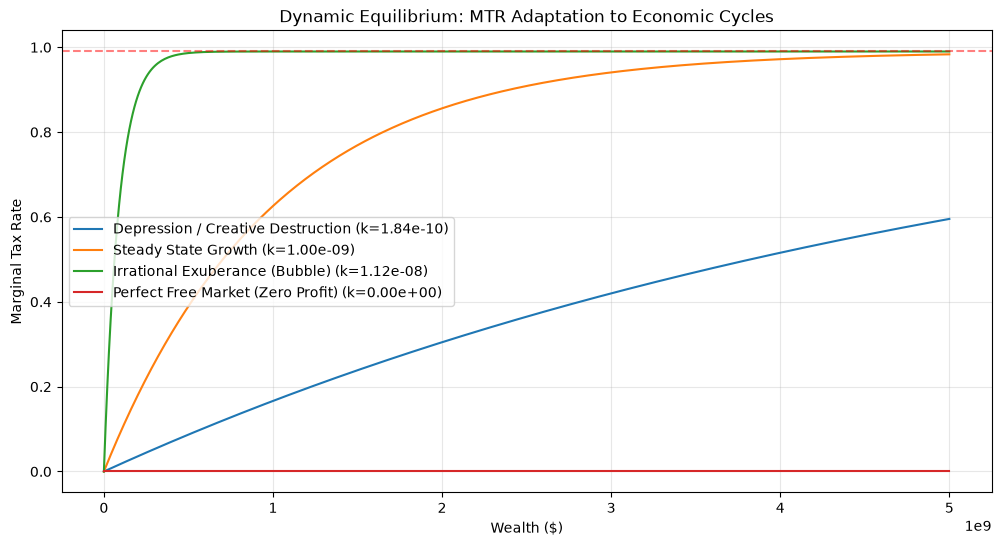

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_dynamic_k(systemic_profit, macro_variance, lambda_scale=1e-8, gamma=5.0):
    """
    Calculates the dynamic decay constant based on real-time economic indicators.
    """
    # If profit is zero or negative, k is zero (standby mode)
    if systemic_profit <= 0:
        return 0.0
    
    return lambda_scale * systemic_profit * np.exp(gamma * macro_variance)

# Simulate different economic environments
scenarios = {
    "Depression / Creative Destruction": {"profit": 0.05, "variance": -0.2},
    "Steady State Growth": {"profit": 0.10, "variance": 0.0},
    "Irrational Exuberance (Bubble)": {"profit": 0.25, "variance": 0.3},
    "Perfect Free Market (Zero Profit)": {"profit": 0.00, "variance": 0.0}
}

wealth_levels = np.linspace(0, 5_000_000_000, 500)
plt.figure(figsize=(12, 6))

for label, params in scenarios.items():
    k_val = calculate_dynamic_k(params["profit"], params["variance"])
    # Using the MTR function from Section 1
    mtr_rates = 0.99 * (1 - np.exp(-k_val * wealth_levels))
    
    plt.plot(wealth_levels, mtr_rates, label=f"{label} (k={k_val:.2e})")

plt.axhline(y=0.99, color='r', linestyle='--', alpha=0.5)
plt.title('Dynamic Equilibrium: MTR Adaptation to Economic Cycles')
plt.xlabel('Wealth ($)')
plt.ylabel('Marginal Tax Rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()